# Bias Detector v3 — RAM Optimized

## All RAM optimizations in this version

| Fix | Technique | Savings |
|-----|-----------|---------|
| Drop unused columns on load | Keep only `sentence`, `article`, `Label_bias` | ~30% DataFrame RAM |
| Drop intermediate text columns | Remove `sentence`, `article`, `heavy_sentence`, `lemmatized_sentence` after use | ~50% DataFrame RAM |
| Delete full df + train_df after splitting | Only keep 3 split subsets in memory | Eliminates full-copy overhead |
| Dynamic padding (DataCollatorWithPadding) | Pad per-batch to longest sequence, not MAX_LEN=256 globally | ~40% tokenization RAM |
| `gradient_checkpointing=True` | Recompute activations during backward instead of storing | ~40% GPU RAM during training |
| `fp16=True` on GPU | Half-precision model + optimizer states | ~50% GPU RAM |
| `gradient_accumulation_steps=2` | Effective batch 16 with only 8 in GPU memory at once | Halves activation RAM |
| `save_total_limit=1` | Only 1 checkpoint kept on disk | Disk + I/O RAM |
| `dataloader_pin_memory=False` | Don't pre-pin CPU memory | Reduces CPU RAM |
| BART fp16 on GPU | Zero-shot model in half precision | ~50% BART GPU RAM |
| Smaller zero-shot batch (8 vs 16) | Less peak activation RAM per forward pass | Reduces BART peak RAM |
| Aggressive `free_memory()` after each stage | gc.collect() + cuda.empty_cache() between stages | Prevents accumulation |

In [1]:
# ============================================================
# CELL 1: Install dependencies — run this first, then restart
# ============================================================
!pip install vaderSentiment lxml openpyxl --quiet
!pip install --upgrade transformers datasets accelerate --quiet
!python -m spacy download en_core_web_sm --quiet
print("All dependencies installed. Restart the runtime if this is your first run.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed. Restart the runtime if this is your first run.


In [2]:
# ============================================================
# CELL 2: Imports
# ============================================================
import gc
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import unicodedata
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import spacy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from google.colab import drive
from datasets import Dataset

warnings.filterwarnings('ignore')

DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {'GPU (cuda:0)' if DEVICE == 0 else 'CPU'}")

def free_memory(*objects):
    """Delete objects, run gc, and empty CUDA/XLA cache."""
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Memory freed.")

Using device: CPU


In [4]:
# ============================================================
# CELL 3: Load dataset — keep only needed columns
# RAM FIX: Drop all unused columns right after loading.
# The original dataset has many columns we never use.
# ============================================================
drive.mount('/content/drive')

filepath = '/content/drive/MyDrive/Colab_Notebooks/archive/labeled_dataset.xlsx'
try:
    _raw = pd.read_excel(filepath)
    print(f"Loaded {len(_raw):,} rows. All columns: {_raw.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: '{filepath}' not found.")
    raise

# Keep only the columns we actually need
KEEP_COLS = ['sentence', 'article', 'Label_bias']
missing = [c for c in KEEP_COLS if c not in _raw.columns]
if missing:
    raise ValueError(f"Expected columns not found: {missing}")

df = _raw[KEEP_COLS].copy()
del _raw
gc.collect()
print(f"Kept {len(KEEP_COLS)} columns, dropped the rest. Shape: {df.shape}")
print(df.head())

Mounted at /content/drive
Loaded 1,700 rows. All columns: ['Unnamed: 0', 'sentence', 'news_link', 'outlet', 'topic', 'type', 'group_id', 'num_sent', 'Label_bias', 'Label_opinion', 'article', 'biased_words4']
Kept 3 columns, dropped the rest. Shape: (1700, 3)
                                            sentence  \
0  YouTube is making clear there will be no “birt...   
1  The increasingly bitter dispute between Americ...   
2  So while there may be a humanitarian crisis dr...   
3  A professor who teaches climate change classes...   
4  Looking around the United States, there is nev...   

                                             article  Label_bias  
0  YouTube says no ‘deepfakes’ or ‘birther’ video...      Biased  
1  FRISCO, Texas — The increasingly bitter disput...  Non-biased  
2  Speaking to the country for the first time fro...      Biased  
3  A professor who teaches climate change classes...  Non-biased  
4  The left has a thing for taking babies hostage...      Biased  


In [5]:
# ============================================================
# CELL 4: Text preprocessing — two tracks
# RAM FIX: Drop intermediate columns as soon as they're no longer needed.
# ============================================================

_RE_MULTI_SPACE = re.compile(r'\s+')
_RE_NON_ALPHA   = re.compile(r'[^a-zA-Z\s]')

def light_clean(text):
    """Minimal cleaning for RoBERTa: strip HTML, fix unicode, normalise whitespace."""
    if not isinstance(text, str):
        return ""
    text = BeautifulSoup(text, 'lxml').get_text()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = _RE_MULTI_SPACE.sub(' ', text)
    return text.strip()

def heavy_clean(text):
    """Full cleaning for VADER: lowercase, remove non-alpha."""
    if not isinstance(text, str):
        return ""
    text = light_clean(text).lower()
    text = _RE_NON_ALPHA.sub('', text)
    text = _RE_MULTI_SPACE.sub(' ', text)
    return text.strip()

# Light-clean (for RoBERTa)
tqdm.pandas(desc="Light-cleaning sentences")
df['clean_sentence'] = df['sentence'].progress_apply(light_clean)

# Heavy-clean (for VADER)
tqdm.pandas(desc="Heavy-cleaning sentences")
df['heavy_sentence'] = df['sentence'].progress_apply(heavy_clean)

# RAM FIX: Drop raw sentence/article columns — we have clean versions now
df.drop(columns=['sentence', 'article'], inplace=True)
gc.collect()
print(f"Preprocessing complete. DataFrame shape: {df.shape}")
print(f"Columns kept: {df.columns.tolist()}")

Light-cleaning sentences:   0%|          | 0/1700 [00:00<?, ?it/s]

Heavy-cleaning sentences:   0%|          | 0/1700 [00:00<?, ?it/s]

Preprocessing complete. DataFrame shape: (1700, 3)
Columns kept: ['Label_bias', 'clean_sentence', 'heavy_sentence']


In [6]:
# ============================================================
# CELL 5: SpaCy lemmatization + VADER
# RAM FIX: Drop heavy_sentence after lemmatization is done.
# ============================================================
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
except OSError:
    print("SpaCy model not found. Run Cell 1 and restart.")
    raise

def batch_lemmatize(texts, batch_size=256, desc="SpaCy"):
    results = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts), desc=desc):
        tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
        results.append(" ".join(tokens))
    return results

df['lemmatized_sentence'] = batch_lemmatize(df['heavy_sentence'].tolist(), desc="Lemmatizing")

# RAM FIX: Drop heavy_sentence — lemmatized version is all VADER needs
df.drop(columns=['heavy_sentence'], inplace=True)
gc.collect()

# VADER sentiment
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    if not isinstance(text, str) or not text:
        return 0.0
    return analyzer.polarity_scores(text)['compound']

tqdm.pandas(desc="VADER — sentences")
df['vader_sentiment'] = df['lemmatized_sentence'].progress_apply(vader_compound)

# RAM FIX: Drop lemmatized text — VADER scores are stored, text no longer needed
df.drop(columns=['lemmatized_sentence'], inplace=True)

# Also unload SpaCy model from memory
nlp.vocab.reset_vectors()
del nlp
gc.collect()

print(f"SpaCy + VADER complete. DataFrame shape: {df.shape}")
print(df.dtypes)

Lemmatizing:   0%|          | 0/1700 [00:00<?, ?it/s]

VADER — sentences:   0%|          | 0/1700 [00:00<?, ?it/s]

SpaCy + VADER complete. DataFrame shape: (1700, 3)
Label_bias          object
clean_sentence      object
vader_sentiment    float64
dtype: object


In [7]:
# ============================================================
# CELL 6: Label mapping and dataset splitting
# ============================================================

ground_truth_col = 'Label_bias'

id2label   = {0: "biased", 1: "non-biased"}
label2id   = {"biased": 0, "non-biased": 1}
NUM_LABELS = 2
ZEROSHOT_CANDIDATE_LABELS = ["biased", "non-biased", "neutral"]

bias_label_mapping = {
    'biased':     'biased',
    'non-biased': 'non-biased',
    'bias':       'biased',
    'none':       'non-biased',
}

print(f"Raw label distribution:\n{df[ground_truth_col].value_counts()}")

df['ground_truth_bias_label'] = df[ground_truth_col].astype(str).str.lower().map(bias_label_mapping)

initial = len(df)
df.dropna(subset=['ground_truth_bias_label'], inplace=True)
print(f"\nDropped {initial - len(df)} unmapped rows. Remaining: {len(df):,}")

df['labels'] = df['ground_truth_bias_label'].map(label2id).astype(int)

# Drop the original Label_bias column — we have ground_truth_bias_label + labels
df.drop(columns=[ground_truth_col], inplace=True)
gc.collect()

print(f"\nLabel distribution:\n{df['ground_truth_bias_label'].value_counts()}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['ground_truth_bias_label']
)
train_df_ft, eval_df_ft = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df['ground_truth_bias_label']
)

# RAM FIX: Delete the full df and train_df — we only need the three split subsets
del df, train_df
gc.collect()

print(f"\nSplit — Train: {len(train_df_ft)} | Val: {len(eval_df_ft)} | Test: {len(test_df)}")

Raw label distribution:
Label_bias
Biased          1018
Non-biased       533
No agreement     149
Name: count, dtype: int64

Dropped 149 unmapped rows. Remaining: 1,551

Label distribution:
ground_truth_bias_label
biased        1018
non-biased     533
Name: count, dtype: int64

Split — Train: 1054 | Val: 186 | Test: 311


In [8]:
# ============================================================
# CELL 7: Compute class weights
# ============================================================

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df_ft['labels'].values
)
CLASS_WEIGHTS = torch.tensor(class_weights_array, dtype=torch.float).to(TORCH_DEVICE)
print(f"Class weights — biased: {CLASS_WEIGHTS[0]:.4f}, non-biased: {CLASS_WEIGHTS[1]:.4f}")

class WeightedTrainer(Trainer):
    """Trainer subclass that uses class-weighted CrossEntropyLoss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer defined.")

Class weights — biased: 0.7616, non-biased: 1.4558
WeightedTrainer defined.


In [9]:
# ============================================================
# CELL 8: Zero-shot classification (facebook/bart-large-mnli)
# RAM FIX: Run with smaller batch size and delete model + all
#          intermediate results immediately after evaluation.
# ============================================================
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

ZS_MODEL = "facebook/bart-large-mnli"
print(f"Loading zero-shot classifier ({ZS_MODEL})...")

zs_classifier = pipeline(
    "zero-shot-classification",
    model=ZS_MODEL,
    device=DEVICE,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,  # RAM FIX: fp16 on GPU halves model memory
)

test_sentences_raw = test_df['clean_sentence'].tolist()
BATCH_ZS = 8  # RAM FIX: smaller batch (was 16) to reduce peak activation memory

zs_raw_results = []
for i in tqdm(range(0, len(test_sentences_raw), BATCH_ZS), desc="Zero-shot batches"):
    batch = test_sentences_raw[i:i+BATCH_ZS]
    zs_raw_results.extend(zs_classifier(batch, ZEROSHOT_CANDIDATE_LABELS))

zs_preds = [r['labels'][0] if r and r['labels'] else 'unknown' for r in zs_raw_results]

# Evaluate
y_true_zs = test_df['ground_truth_bias_label'].tolist()
y_pred_zs = [p if p in id2label.values() else 'non-biased' for p in zs_preds]

print("\n--- Zero-Shot Baseline ---")
print(f"Accuracy: {accuracy_score(y_true_zs, y_pred_zs):.4f}")
print(classification_report(y_true_zs, y_pred_zs, labels=list(id2label.values()), zero_division=0))

from sklearn.metrics import f1_score
zs_f1_per_class = {
    lbl: f1_score(y_true_zs, y_pred_zs, labels=[lbl], average='macro', zero_division=0)
    for lbl in id2label.values()
}

# RAM FIX: Aggressively free BART (~1.6 GB) before loading RoBERTa
free_memory(zs_classifier, zs_raw_results, test_sentences_raw)
print("Zero-shot done. BART unloaded from memory.")

Loading zero-shot classifier (facebook/bart-large-mnli)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Zero-shot batches:   0%|          | 0/39 [00:00<?, ?it/s]


--- Zero-Shot Baseline ---
Accuracy: 0.6495
              precision    recall  f1-score   support

      biased       0.76      0.68      0.72       204
  non-biased       0.49      0.60      0.54       107

    accuracy                           0.65       311
   macro avg       0.63      0.64      0.63       311
weighted avg       0.67      0.65      0.66       311

Memory freed.
Zero-shot done. BART unloaded from memory.


In [10]:
# ============================================================
# CELL 9: Fine-tuning with RoBERTa-base
# RAM FIXES:
#   - Dynamic padding instead of padding="max_length"
#     (most sentences are short — static padding to 256 wastes huge RAM)
#   - gradient_checkpointing=True: trades compute for ~40% less GPU RAM
#   - fp16=True on GPU: halves model + optimizer memory
#   - gradient_accumulation_steps=2: effective batch 16 with only 8 in memory
#   - dataloader_pin_memory=False: saves CPU RAM on Colab
#   - save_total_limit=1: only keep the single best checkpoint on disk
# ============================================================
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

FT_MODEL   = "roberta-base"
MAX_LEN    = 256
BATCH_SZ   = 8
NUM_EPOCHS = 4

tokenizer_ft = AutoTokenizer.from_pretrained(FT_MODEL)

# RAM FIX: Use DataCollatorWithPadding for dynamic padding
# Each batch is padded only to the longest sequence IN THAT BATCH,
# not to MAX_LEN=256 globally. Dramatically reduces memory for short-text batches.
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)

def tokenize_fn(examples):
    # NO padding here — DataCollatorWithPadding handles it per-batch
    return tokenizer_ft(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,   # RAM FIX: dynamic padding
    )

def make_ds(df_subset):
    return Dataset.from_pandas(
        df_subset[['clean_sentence', 'labels']]
        .rename(columns={'clean_sentence': 'text'})
        .reset_index(drop=True)
    )

print("Tokenizing datasets...")
tok_train = make_ds(train_df_ft).map(tokenize_fn, batched=True, remove_columns=['text'])
tok_eval  = make_ds(eval_df_ft).map(tokenize_fn,  batched=True, remove_columns=['text'])
tok_test  = make_ds(test_df).map(tokenize_fn,     batched=True, remove_columns=['text'])

# RAM FIX: Free split DataFrames — tokenized HF datasets are all we need now
free_memory(train_df_ft, eval_df_ft)

# Load model
model_ft = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# RAM FIX: Gradient checkpointing — recomputes activations during backward pass
# instead of storing them. ~40% less GPU RAM at the cost of ~20% slower training.
model_ft.gradient_checkpointing_enable()

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    acc   = accuracy_score(p.label_ids, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        p.label_ids, preds, average='macro', zero_division=0
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

total_steps  = (len(tok_train) // BATCH_SZ) * NUM_EPOCHS
warmup_steps = max(50, int(total_steps * 0.1))
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

USE_FP16 = torch.cuda.is_available()  # fp16 only on GPU (not CPU/XLA)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SZ,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,    # RAM FIX: accumulate 2 steps = effective batch 16
    learning_rate=2e-5,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    fp16=USE_FP16,                    # RAM FIX: fp16 halves GPU memory usage
    logging_steps=50,
    report_to="none",
    optim="adamw_torch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,               # RAM FIX: only keep best checkpoint, not all epochs
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    dataloader_pin_memory=False,      # RAM FIX: don't pin CPU memory (helps on Colab)
)

trainer = WeightedTrainer(
    model=model_ft,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_eval,
    processing_class=tokenizer_ft,
    data_collator=data_collator,      # RAM FIX: dynamic padding collator
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("\nStarting fine-tuning...")
trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6148', 'grad_norm': '34.62', 'learning_rate': '6.132e-06', 'epoch': '3.03'}
{'loss': '0.3681', 'grad_norm': '11.68', 'learning_rate': '1.415e-06', 'epoch': '3.788'}
{'eval_loss': '0.7076', 'eval_accuracy': '0.7849', 'eval_precision': '0.7653', 'eval_recall': '0.7841', 'eval_f1': '0.7709', 'eval_runtime': '37.98', 'eval_samples_per_second': '4.898', 'eval_steps_per_second': '0.316', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '4430', 'train_samples_per_second': '0.952', 'train_steps_per_second': '0.06', 'train_loss': '0.8124', 'epoch': '4'}


TrainOutput(global_step=264, training_loss=0.8124396060452317, metrics={'train_runtime': 4430.349, 'train_samples_per_second': 0.952, 'train_steps_per_second': 0.06, 'train_loss': 0.8124396060452317, 'epoch': 4.0})


--- Fine-tuned Model: Validation Set ---
{'eval_loss': '0.6334', 'eval_accuracy': '0.7957', 'eval_precision': '0.7753', 'eval_recall': '0.7923', 'eval_f1': '0.7811', 'eval_runtime': '39.02', 'eval_samples_per_second': '4.766', 'eval_steps_per_second': '0.308', 'epoch': '4'}
{'eval_loss': 0.6334492564201355, 'eval_accuracy': 0.7956989247311828, 'eval_precision': 0.7753378378378378, 'eval_recall': 0.7922643442622951, 'eval_f1': 0.781122259383129, 'eval_runtime': 39.0241, 'eval_samples_per_second': 4.766, 'eval_steps_per_second': 0.308, 'epoch': 4.0}

--- Fine-tuned Model: Test Set ---
Test Accuracy: 0.8232

Classification Report:
              precision    recall  f1-score   support

      biased       0.88      0.84      0.86       204
  non-biased       0.72      0.79      0.75       107

    accuracy                           0.82       311
   macro avg       0.80      0.81      0.81       311
weighted avg       0.83      0.82      0.82       311

Memory freed.


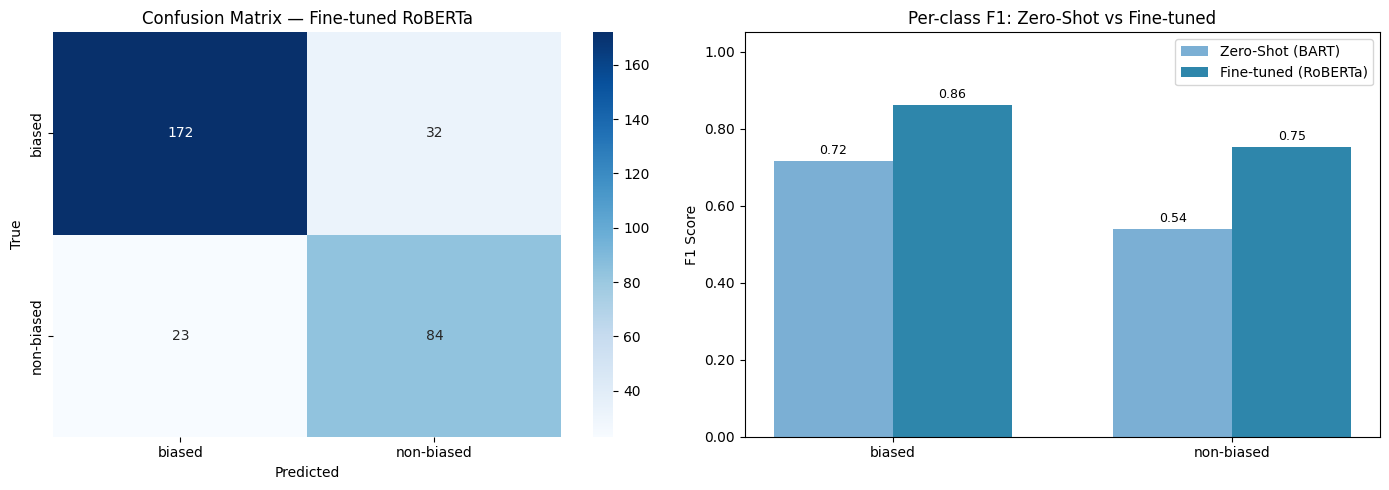

Chart saved to Google Drive.


In [11]:
# ============================================================
# CELL 10: Final evaluation + visualizations
# ============================================================

print("\n--- Fine-tuned Model: Validation Set ---")
eval_res = trainer.evaluate()
print(eval_res)

print("\n--- Fine-tuned Model: Test Set ---")
preds_out  = trainer.predict(tok_test)
pred_ids   = np.argmax(preds_out.predictions, axis=1)
true_ids   = preds_out.label_ids

pred_labels_str = [id2label[p] for p in pred_ids]
true_labels_str = [id2label[l] for l in true_ids]

ft_accuracy = accuracy_score(true_labels_str, pred_labels_str)
print(f"Test Accuracy: {ft_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(
    true_labels_str, pred_labels_str,
    target_names=list(id2label.values()),
    zero_division=0
))

# RAM FIX: Free test dataset and predictions after extracting labels
free_memory(tok_test, preds_out)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
label_names = list(id2label.values())
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix — Fine-tuned RoBERTa")

# ── Per-class F1 comparison ───────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1

ft_f1_per_class = {
    lbl: f1(true_labels_str, pred_labels_str, labels=[lbl], average='macro', zero_division=0)
    for lbl in label_names
}

x = np.arange(len(label_names))
w = 0.35
bars_zs = [zs_f1_per_class.get(l, 0) for l in label_names]
bars_ft = [ft_f1_per_class.get(l, 0) for l in label_names]

axes[1].bar(x - w/2, bars_zs, w, label='Zero-Shot (BART)', color='#7BAFD4')
axes[1].bar(x + w/2, bars_ft, w, label='Fine-tuned (RoBERTa)', color='#2E86AB')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_names)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-class F1: Zero-Shot vs Fine-tuned")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.2f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab_Notebooks/bias_detector_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive.")

In [12]:
# ============================================================
# CELL 11: Save model + inference function
# ============================================================

SAVE_PATH = '/content/drive/MyDrive/Colab_Notebooks/bias_detector_roberta'
trainer.save_model(SAVE_PATH)
tokenizer_ft.save_pretrained(SAVE_PATH)
print(f"Model saved to: {SAVE_PATH}")

# Load lean inference model (cpu to avoid double-loading on GPU)
_inf_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
_inf_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(TORCH_DEVICE)
_inf_model.eval()

def predict_bias(text: str, threshold: float = 0.5) -> dict:
    """Predict bias for any sentence. Returns label, confidence, and per-class scores."""
    cleaned = light_clean(text)
    inputs  = _inf_tokenizer(
        cleaned, return_tensors='pt',
        truncation=True, max_length=MAX_LEN, padding=True
    ).to(TORCH_DEVICE)
    with torch.no_grad():
        logits = _inf_model(**inputs).logits
    probs      = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_id    = int(np.argmax(probs))
    confidence = float(probs[pred_id])
    label      = id2label[pred_id] if confidence >= threshold else "uncertain"
    return {
        "label":      label,
        "confidence": round(confidence, 4),
        "scores":     {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}
    }

# Demo
test_examples = [
    "The radical left continues to destroy everything America stands for.",
    "The committee voted 7-3 in favour of the new infrastructure bill.",
    "Scientists published a new study on climate change projections.",
    "The corrupt politician once again betrayed the hard-working people of this nation.",
]
print("\n--- Inference Demo ---")
for ex in test_examples:
    r = predict_bias(ex)
    print(f"\n{ex[:80]}")
    print(f"  → {r['label']} (confidence: {r['confidence']:.2%}) | scores: {r['scores']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/Colab_Notebooks/bias_detector_roberta


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Inference Demo ---

The radical left continues to destroy everything America stands for.
  → biased (confidence: 97.98%) | scores: {'biased': 0.9798, 'non-biased': 0.0202}

The committee voted 7-3 in favour of the new infrastructure bill.
  → non-biased (confidence: 98.67%) | scores: {'biased': 0.0133, 'non-biased': 0.9867}

Scientists published a new study on climate change projections.
  → non-biased (confidence: 98.64%) | scores: {'biased': 0.0136, 'non-biased': 0.9864}

The corrupt politician once again betrayed the hard-working people of this natio
  → biased (confidence: 97.65%) | scores: {'biased': 0.9765, 'non-biased': 0.0235}
